## Uncover if needed to install


In [ ]:
#!pip install distrax matplotlib optax tensorflow keras pandas numpy

In [ ]:
#!pip install -e "C:/path/to/CoinEM-main(replace with the path to the CoinEM-main folder)"

# Bayesian neural network

First, we load the modules we need:

In [ ]:
import jax.numpy as jnp
import jax
from jaxtyping import Array, Float
from dataclasses import dataclass
import jax.random as jr
import matplotlib.pyplot as plt
import distrax as dx

from coinem.model import AbstractModel
from coinem.dataset import Dataset
import numpy as np
import os
import optax as ox

from coinem.zoo import coin_svgd, pgd, adam_svgd, soul, m_svgd_em
from coinem.marginal_zoo import marginal_coin_svgd
from keras.datasets import mnist
import pandas as pd

from jax import vmap

In [2]:
method_markers = {
    'SVGD-EM': 'o',
    'M-SVGD-EM(0.3)': 's',
    'M-SVGD-EM(0.5)': '^',
    'M-SVGD-EM(0.9)': 'D',
    'PGD': 'X',
    'SOUL': 'P'
}

method_colors = {
    'SVGD-EM': '#8B0000',
    'M-SVGD-EM(0.3)': '#FF3333',
    'M-SVGD-EM(0.5)': '#FF8C00',
    'M-SVGD-EM(0.9)': '#228B22',
    'PGD': '#9370DB',
    'SOUL': '#20B2AA'
}


In [4]:
save_dir = "figures"
os.makedirs(save_dir, exist_ok=True)
# save_dir = "figures_MedianRBF"
# os.makedirs(save_dir, exist_ok=True)

In [52]:
import time
start =time.time()

## Model


In [5]:
@dataclass
class BayesNN(AbstractModel):
    """Base class for p(θ, x)."""
    
    def log_prob(self, latent: Float[Array, "D"], theta: Float[Array, "Q"], data: Dataset) -> Float[Array, ""]:
        """Compute gradient of the objective function at x.

        Args:
            latent (Float[Array, "D"]): Input weights of shape (D,).
            theta (Float[Array, "Q"]): Parameters of shape (2,).

        Returns:
            Float[Array, ""]: log-probability of the data.
        """
        X = data.X # [Batchsize, 28, 28]
        y = data.y # [Batchsize, 1]

        # Compute prior:
        log_prior_w = dx.Normal(0.0, jnp.exp(2.0 * theta["alpha"].squeeze())).log_prob(latent["w"].ravel()).sum() 
        log_prior_v = dx.Normal(0.0, jnp.exp(2.0 * theta["beta"].squeeze())).log_prob(latent["v"].ravel()).sum()


        def _log_nn(image):
            # Log of the network's output when evaluated at image with weights w, v.
            return jax.nn.log_softmax(jnp.dot(latent["v"], jnp.tanh(jnp.dot(latent["w"], image.flatten())))) 


        def _log_nn_vec(images):
            # _log_nn vectorized over particles.
            return jax.vmap(_log_nn)(images)


        def _log_likelihood(images, labels):
            # Log-likelihood for set of images and labels, vectorized over particles.
            return vmap(lambda v, l : v[l])(_log_nn_vec(images), labels).sum()


        # Compute log-probability.
        return  (_log_likelihood(X, y) + log_prior_w + log_prior_v) / data.n # log p(y|x) + log p(x|theta) 
    

    def optimal_theta(self, latent_particles: Float[Array, "N D *"]) -> Float[Array, "Q *"]:
        """Optimal parameter for weight cloud w."""
        mom2 = (jax.vmap(_normsq)(latent_particles["w"])).mean()  # Second moment
        mom4 = (jax.vmap(_normsq)(latent_particles["v"])).mean()  # Fourth moment


        return {"alpha": jnp.log(mom2/(latent_particles["w"][0].size))/2, 
                "beta": jnp.log(mom4/(latent_particles["v"][0].size))/2}
        
def _normsq(x):
    # Squared Frobenius norm of x.
    v = x.reshape((x.size))
    return jnp.dot(v, v)

Next, we load and curate the dataset:

In [6]:
#@title Load, subsample, and normalize MNIST dataset.
(images, labels), _ = mnist.load_data()
images = np.array(images).astype(float)
labels = np.array(labels).astype(int)

# Keep only datapoints with labels 4 and 9:
indices = (labels == 4) | (labels == 9)
labels = labels[indices]
images = images[indices, :, :]

# Relabel as 4 as 0 and 9 as 1:
for n in range(labels.size):
    if labels[n] == 4:
        labels[n] = 0
    else:
        labels[n] = 1

# Sub-sample 1000 images:
from sklearn.model_selection import train_test_split
images, _, labels, _ = train_test_split(images, labels, train_size=1000,
                                        random_state=0)

# Normalize non-zero entries so that they have mean zero and unit standard 
# across the dataset:'''
i = images.std(0) != 0
images[:, i] = (images[:, i] - images[:, i].mean(0))/images[:, i].std(0)

# Split data into 80/20 training and testing sets:
itrain, itest, ltrain, ltest = train_test_split(images, labels, test_size=0.2,
                                                random_state=0)

from coinem.dataset import Dataset

data = Dataset(jnp.array(itrain), jnp.array(ltrain).reshape(-1, 1))


We then implement the algorithms. They take in the following inputs:

*   itrain : training set labels,
*   itrain : training set images,
*   itest : test set labels,
*   itest : test set images,
*   h : step-size,
*   K : number of steps,
*   N : number of particles,
*   a : 1-dimensional vector with initial alpha guess,
*   b : 1-dimensional vector with initial beta guess,
*   w : Dw x N matrix storing the input layer weights of the initial particle cloud,
*   v : Dv x N matrix storing the output layer weights of the initial particle cloud.

They return the following outputs:

*   a : K-dimensional vector of alpha estimates,
*   b : K-dimensional vector of beta estimates,
*   w : Dw x N matrix storing the input layer weights of the final particle cloud,
*   v : Dv x N matrix storing the output layer weights of the final particle cloud,
*   lppd : log pointwise predictive density (LPPD) as a function of k,
*   error : test error as a function of k.

We can now run the algorithms using an 80/20 training/test split of the data:

In [ ]:
h = 1e-1 # Step-size. 
K = 500  # Number of steps.
N = 10  # Number of particles.

key = jr.PRNGKey(102)
#(0,1,2,5)
alpha = jnp.array(0.0) # HIGHLY SENSITIVE TO STARTING POINTS
beta = jnp.array(0.0)


# Initialize particle cloud by sampling prior:
w_init = jnp.exp(alpha) * jr.normal(key, (N, 40, 28**2))  # Input layer weights.
v_init = jnp.exp(beta) * jr.normal(key, (N, 2, 40))  # Output layer weights.


theta_init = {"alpha": alpha, "beta": beta}
latent_init = {"w": w_init, "v": v_init}

model = BayesNN()
latent_optimiser = ox.adagrad(0.1)
theta_optimiser = ox.adagrad(0.1)

# x_coin, theta_coin = coin_svgd(model, data, latent_init, theta_init, K, alpha=100.0)
# x_pgd, theta_pgd = pgd(model, data, latent_init, theta_init, K, latent_step_size=1e-2, theta_step_size=1e-2)
# x_adam, theta_adam = adam_svgd(model, data, latent_init, theta_init, K, latent_step_size=1e-3, theta_step_size=1e-3)
# x_soul, theta_soul = soul(model, data, latent_init, theta_init, K, latent_step_size=1e-2, theta_step_size=1e-2)
x_00, theta_00 = m_svgd_em(model, data, latent_init, theta_init, latent_optimiser, theta_optimiser, K, 0, 0)
x_03, theta_03 = m_svgd_em(model, data, latent_init, theta_init, latent_optimiser, theta_optimiser, K, 0.3, 0.3)
x_05, theta_05 = m_svgd_em(model, data, latent_init, theta_init, latent_optimiser, theta_optimiser, K, 0.5, 0.5)
x_09, theta_09 = m_svgd_em(model, data, latent_init, theta_init, latent_optimiser, theta_optimiser, K, 0.9, 0.9)

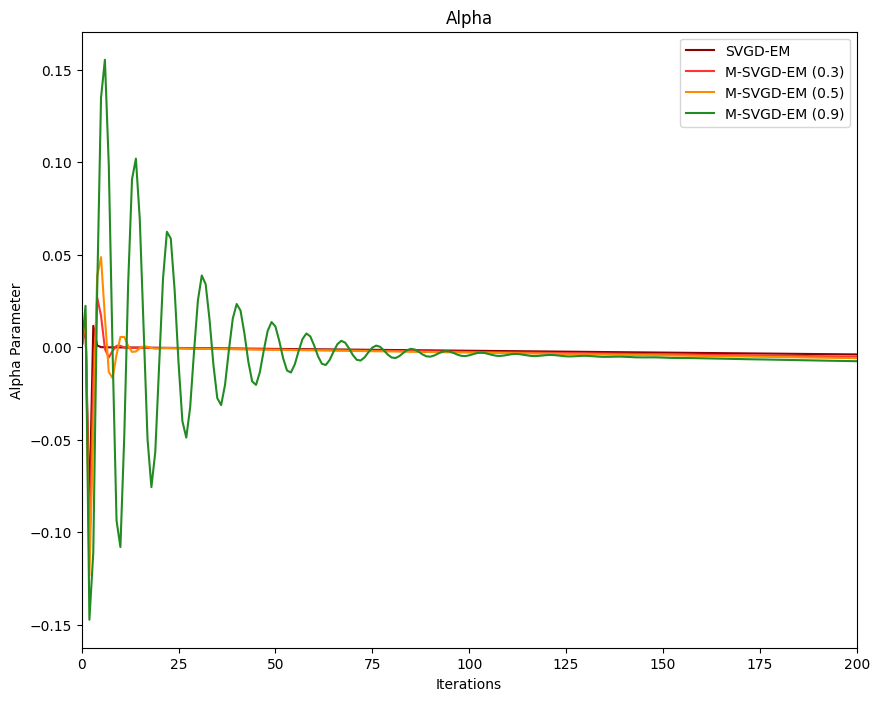

In [11]:
plt.figure(figsize=(10, 8))
plt.plot(range(len(theta_00["alpha"])), theta_00["alpha"], label="SVGD-EM", color='#8B0000')
plt.plot(range(len(theta_03["alpha"])), theta_03["alpha"], label="M-SVGD-EM (0.3)", color='#FF3333')
plt.plot(range(len(theta_05["alpha"])), theta_05["alpha"], label="M-SVGD-EM (0.5)", color='#FF8C00')
plt.plot(range(len(theta_09["alpha"])), theta_09["alpha"], label="M-SVGD-EM (0.9)", color='#228B22')
#plt.plot(theta_marginal_coin["alpha"], label="Marginal Coin-SVGD")
plt.legend()
plt.xlim(0,200)
plt.xlabel('Iterations')
plt.ylabel('Alpha Parameter')
plt.title('Alpha')
plt.savefig(os.path.join(save_dir, f'alpha_parameter_{alpha}_initial.pdf'), dpi=300, bbox_inches='tight')
plt.show()

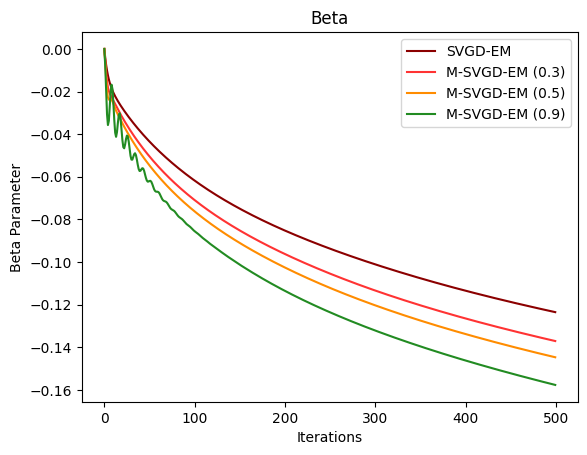

In [12]:
plt.figure(figsize=(6.4, 4.8))
plt.plot(range(len(theta_00["beta"])), theta_00["beta"], label="SVGD-EM", color='#8B0000')
plt.plot(range(len(theta_03["beta"])), theta_03["beta"], label="M-SVGD-EM (0.3)", color='#FF3333')
plt.plot(range(len(theta_05["beta"])), theta_05["beta"], label="M-SVGD-EM (0.5)", color='#FF8C00')
plt.plot(range(len(theta_09["beta"])), theta_09["beta"], label="M-SVGD-EM (0.9)", color='#228B22')
#plt.plot(theta_marginal_coin["beta"], label="Marginal Coin-SVGD")
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Beta Parameter')
plt.title('Beta')
plt.savefig(os.path.join(save_dir, f'beta_parameter_{beta}_initial.pdf'), dpi=300, bbox_inches='tight')
plt.show()

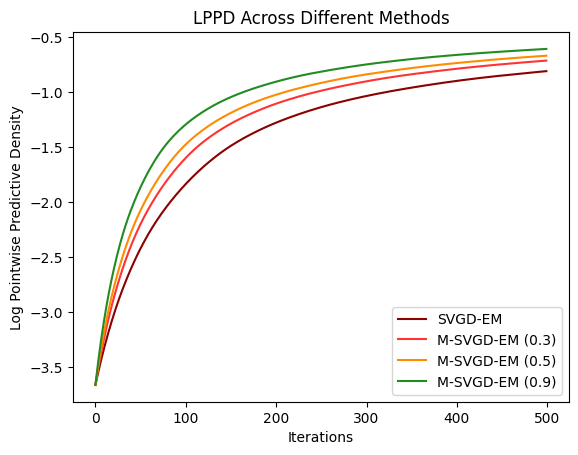

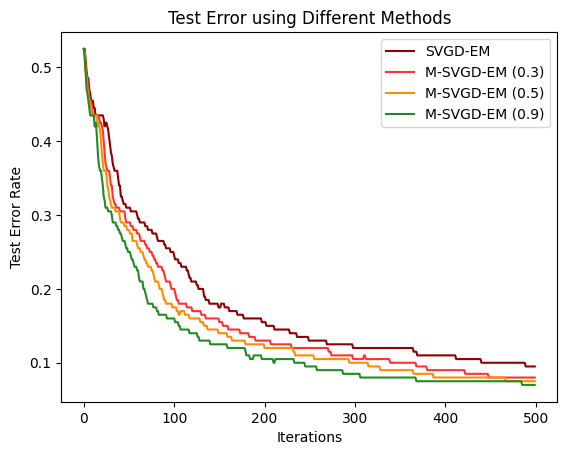

In [13]:
def log_pointwise_predrictive_density(model, latent_particles, images, labels):
    """Returns LPPD for set of (test) images and labels."""

    def _latent_cal(latent):

        def _log_nn(image):
            # Log of the network's output when evaluated at image with weights w, v.
            return jax.nn.log_softmax(jnp.dot(latent["v"], jnp.tanh(jnp.dot(latent["w"], image.flatten())))) 


        def _log_nn_vec(images):
            # _log_nn vectorized over particles.
            return jax.vmap(_log_nn)(images)


        return _log_nn_vec(images)
    
    s = jax.vmap(_latent_cal)(latent_particles).mean(0)
    return vmap(lambda v, l : v[l])(s, labels).mean()




def _predict(model, latent_particles, images):
    """Returns LPPD for set of (test) images and labels."""

    def _latent_cal(latent):

        def _log_nn(image):
            # Log of the network's output when evaluated at image with weights w, v.
            return jax.nn.log_softmax(jnp.dot(latent["v"], jnp.tanh(jnp.dot(latent["w"], image.flatten()))))  


        def _log_nn_vec(images):
            # _log_nn vectorized over particles.
            return jax.vmap(_log_nn)(images)


        return _log_nn_vec(images)
    
    s = jax.vmap(_latent_cal)(latent_particles).mean(0)
    return jnp.argmax(s, axis=1)


def test_error(model, latent_particles, images, labels):
    """Returns fraction of misclassified images in test set."""
    return jnp.abs(labels.squeeze() - _predict(model, latent_particles, images)).mean()

plt.plot(vmap(lambda p: log_pointwise_predrictive_density(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x_00), label="SVGD-EM", color='#8B0000')
plt.plot(vmap(lambda p: log_pointwise_predrictive_density(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x_03), label="M-SVGD-EM (0.3)", color='#FF3333')
plt.plot(vmap(lambda p: log_pointwise_predrictive_density(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x_05), label="M-SVGD-EM (0.5)", color='#FF8C00')
plt.plot(vmap(lambda p: log_pointwise_predrictive_density(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x_09), label="M-SVGD-EM (0.9)", color='#228B22')
#plt.plot(vmap(lambda p: log_pointwise_predrictive_density(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x_marginal_coin), label="Marginal Coin-SVGD")

plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Log Pointwise Predictive Density')
plt.title('LPPD Across Different Methods')
plt.show()

plt.plot(vmap(lambda p: test_error(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x_00), label="SVGD-EM", color='#8B0000')
plt.plot(vmap(lambda p: test_error(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x_03), label="M-SVGD-EM (0.3)", color='#FF3333')
plt.plot(vmap(lambda p: test_error(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x_05), label="M-SVGD-EM (0.5)", color='#FF8C00')
plt.plot(vmap(lambda p: test_error(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x_09), label="M-SVGD-EM (0.9)", color='#228B22')
#plt.plot(vmap(lambda p: test_error(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x_marginal_coin), label="Marginal Coin-SVGD")

plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Test Error Rate')
plt.title('Test Error using Different Methods')
plt.show()

In [72]:

# Set approximation parameters:
h = 1e-1  # Step-size. 
K = 500  # Number of steps.
particle_counts = [5, 10,20]  # Number of particles to test
num_trials = 5  # Number of independent trials

model = BayesNN()
latent_optimiser = ox.adagrad(0.1)
theta_optimiser = ox.adagrad(0.1)

# Dictionary to store results for each particle count and trial
results = {}

for N in particle_counts:
    results[N] = {
        'x_00': [], 'theta_00': [],
        'x_03': [], 'theta_03': [],
        'x_05': [], 'theta_05': [],
        'x_09': [], 'theta_09': []
    }
    
    for trial in range(num_trials):
        # Set a different seed for each trial
        key = jr.PRNGKey(102 + trial)
        #5 initial for alpha and beta 5 min run
        #2 initial for alpha and beta
        alpha = jnp.array(5.0)
        beta = jnp.array(5.0)

        # Initialize particle cloud by sampling prior:
        w_init = jnp.exp(alpha) * jr.normal(key, (N, 40, 28**2))  # Input layer weights.
        v_init = jnp.exp(beta) * jr.normal(key, (N, 2, 40))  # Output layer weights.

        theta_init = {"alpha": alpha, "beta": beta}
        latent_init = {"w": w_init, "v": v_init}

        # Run different methods
        x_00, theta_00 = m_svgd_em(model, data, latent_init, theta_init, latent_optimiser, theta_optimiser, K, 0, 0)
        x_03, theta_03 = m_svgd_em(model, data, latent_init, theta_init, latent_optimiser, theta_optimiser, K, 0.3, 0.3)
        x_05, theta_05 = m_svgd_em(model, data, latent_init, theta_init, latent_optimiser, theta_optimiser, K, 0.5, 0.5)
        x_09, theta_09 = m_svgd_em(model, data, latent_init, theta_init, latent_optimiser, theta_optimiser, K, 0.9, 0.9)
        
        # Store results
        results[N]['x_00'].append(x_00)
        results[N]['theta_00'].append(theta_00)
        results[N]['x_03'].append(x_03)
        results[N]['theta_03'].append(theta_03)
        results[N]['x_05'].append(x_05)
        results[N]['theta_05'].append(theta_05)
        results[N]['x_09'].append(x_09)
        results[N]['theta_09'].append(theta_09)

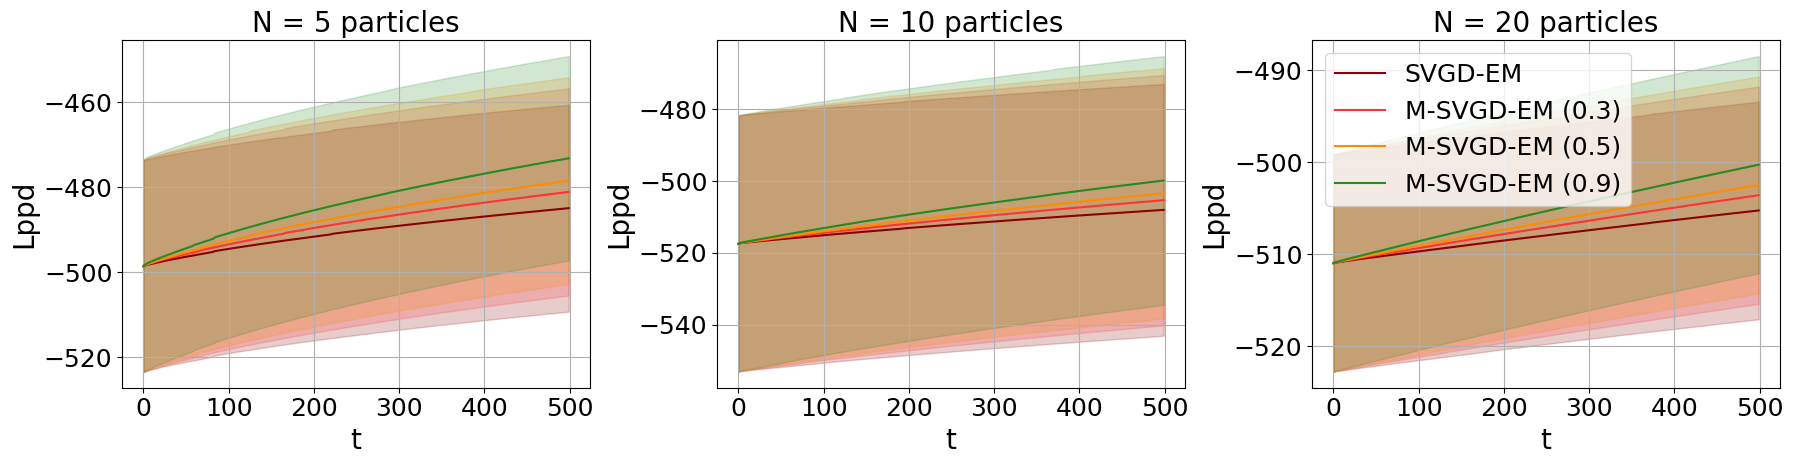

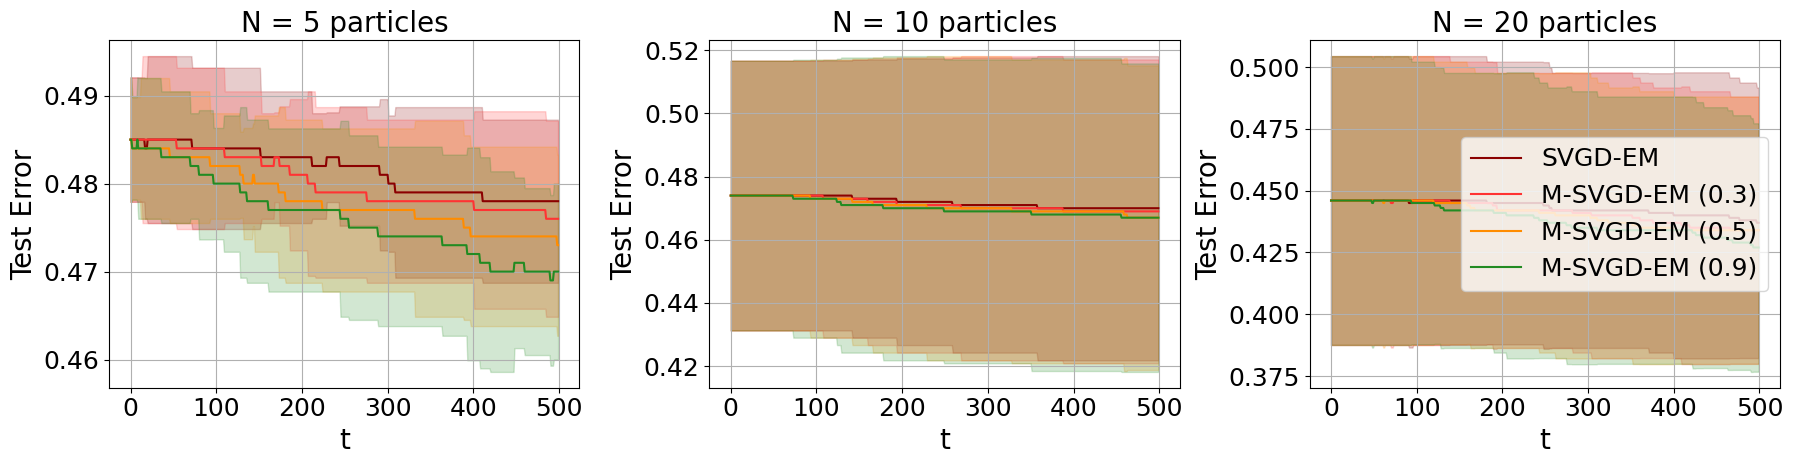

In [ ]:
#VERY HEAVY CAREFUL!
#Lppd
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, N in enumerate(particle_counts):
    ax = axes[i]
    
    # Calculate mean and std of LPPD across trials
    lppd_00 = jnp.stack([vmap(lambda p: log_pointwise_predrictive_density(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x) for x in results[N]['x_00']])
    lppd_03 = jnp.stack([vmap(lambda p: log_pointwise_predrictive_density(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x) for x in results[N]['x_03']])
    lppd_05 = jnp.stack([vmap(lambda p: log_pointwise_predrictive_density(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x) for x in results[N]['x_05']])
    lppd_09 = jnp.stack([vmap(lambda p: log_pointwise_predrictive_density(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x) for x in results[N]['x_09']])
    
    # Calculate means and standard deviations
    lppd_00_mean, lppd_00_std = lppd_00.mean(0), lppd_00.std(0)
    lppd_03_mean, lppd_03_std = lppd_03.mean(0), lppd_03.std(0)
    lppd_05_mean, lppd_05_std = lppd_05.mean(0), lppd_05.std(0)
    lppd_09_mean, lppd_09_std = lppd_09.mean(0), lppd_09.std(0)
    
    # Create x-axis for iterations
    iterations = jnp.arange(K)
    
    # Plot with error bands
    ax.plot(iterations, lppd_00_mean, label="SVGD-EM", color='#8B0000')
    ax.fill_between(iterations, lppd_00_mean - lppd_00_std, lppd_00_mean + lppd_00_std, color='#8B0000', alpha=0.2)
    
    ax.plot(iterations, lppd_03_mean, label="M-SVGD-EM (0.3)", color='#FF3333')
    ax.fill_between(iterations, lppd_03_mean - lppd_03_std, lppd_03_mean + lppd_03_std, color='#FF3333', alpha=0.2)
    
    ax.plot(iterations, lppd_05_mean, label="M-SVGD-EM (0.5)", color='#FF8C00')
    ax.fill_between(iterations, lppd_05_mean - lppd_05_std, lppd_05_mean + lppd_05_std, color='#FF8C00', alpha=0.2)
    
    ax.plot(iterations, lppd_09_mean, label="M-SVGD-EM (0.9)", color='#228B22')
    ax.fill_between(iterations, lppd_09_mean - lppd_09_std, lppd_09_mean + lppd_09_std, color='#228B22', alpha=0.2)
    
    ax.set_xlabel('t', fontsize=20)
    ax.set_ylabel('Lppd', fontsize=20)
    ax.set_title(f'N = {N} particles', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.grid()
ax.legend(fontsize=18)
   

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(save_dir,f'bnn_lppd_5_10_20_{alpha}and{beta}.pdf'), dpi=300, bbox_inches='tight')
plt.show()

# Test Error
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, N in enumerate(particle_counts):
    ax = axes[i]
    
    # Calculate mean and std of test error across trials
    error_00 = jnp.stack([vmap(lambda p: test_error(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x) for x in results[N]['x_00']])
    error_03 = jnp.stack([vmap(lambda p: test_error(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x) for x in results[N]['x_03']])
    error_05 = jnp.stack([vmap(lambda p: test_error(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x) for x in results[N]['x_05']])
    error_09 = jnp.stack([vmap(lambda p: test_error(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x) for x in results[N]['x_09']])
    
    # Calculate means and standard deviations
    error_00_mean, error_00_std = error_00.mean(0), error_00.std(0)
    error_03_mean, error_03_std = error_03.mean(0), error_03.std(0)
    error_05_mean, error_05_std = error_05.mean(0), error_05.std(0)
    error_09_mean, error_09_std = error_09.mean(0), error_09.std(0)
    
    # Create x-axis for iterations
    iterations = jnp.arange(K)
    
    # Plot with error bands
    ax.plot(iterations, error_00_mean, label="SVGD-EM", color='#8B0000')
    ax.fill_between(iterations, error_00_mean - error_00_std, error_00_mean + error_00_std, color='#8B0000', alpha=0.2)
    
    ax.plot(iterations, error_03_mean, label="M-SVGD-EM (0.3)", color='#FF3333')
    ax.fill_between(iterations, error_03_mean - error_03_std, error_03_mean + error_03_std, color='#FF3333', alpha=0.2)
    
    ax.plot(iterations, error_05_mean, label="M-SVGD-EM (0.5)", color='#FF8C00')
    ax.fill_between(iterations, error_05_mean - error_05_std, error_05_mean + error_05_std, color='#FF8C00', alpha=0.2)
    
    ax.plot(iterations, error_09_mean, label="M-SVGD-EM (0.9)", color='#228B22')
    ax.fill_between(iterations, error_09_mean - error_09_std, error_09_mean + error_09_std, color='#228B22', alpha=0.2)
    
    ax.set_xlabel('t', fontsize=20)
    ax.set_ylabel('Test Error', fontsize=20)
    ax.set_title(f'N = {N} particles', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.grid()
ax.legend(fontsize=18)# No need to have the legend multiple times only last plot its fine
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(os.path.join(save_dir,f'bnn_test_error_5_10_20_{alpha}and{beta}.pdf'), dpi=300, bbox_inches='tight')
plt.show()

In [66]:
import optax as ox
import matplotlib.pyplot as plt

from coinem.zoo import coin_svgd, pgd, adam_svgd, soul, m_svgd_em
from coinem.marginal_zoo import marginal_coin_svgd
# Set approximation parameters:
h = 1e-1  # Step-size. 
K = 500  # Number of steps.
N = 10  
num_trials = 10 

# Model and optimizers
model = BayesNN()
latent_optimiser = ox.adagrad(0.1)
theta_optimiser = ox.adagrad(0.1)
results = {}

results[10] = {
        'x_00': [], 'theta_00': [],
        'x_03': [], 'theta_03': [],
        'x_05': [], 'theta_05': [],
        'x_09': [], 'theta_09': []
    }
    
for trial in range(num_trials):

        key = jr.PRNGKey(102 + trial)
        
        alpha = jnp.array(0.0)
        beta = jnp.array(0.0)

        w_init = jnp.exp(alpha) * jr.normal(key, (N, 40, 28**2))  # Input layer weights.
        v_init = jnp.exp(beta) * jr.normal(key, (N, 2, 40))  # Output layer weights.

        theta_init = {"alpha": alpha, "beta": beta}
        latent_init = {"w": w_init, "v": v_init}

        x_00, theta_00 = m_svgd_em(model, data, latent_init, theta_init, latent_optimiser, theta_optimiser, K, 0, 0)
        x_03, theta_03 = m_svgd_em(model, data, latent_init, theta_init, latent_optimiser, theta_optimiser, K, 0.3, 0.3)
        x_05, theta_05 = m_svgd_em(model, data, latent_init, theta_init, latent_optimiser, theta_optimiser, K, 0.5, 0.5)
        x_09, theta_09 = m_svgd_em(model, data, latent_init, theta_init, latent_optimiser, theta_optimiser, K, 0.9, 0.9)
        
        results[N]['x_00'].append(x_00)
        results[N]['theta_00'].append(theta_00)
        results[N]['x_03'].append(x_03)
        results[N]['theta_03'].append(theta_03)
        results[N]['x_05'].append(x_05)
        results[N]['theta_05'].append(theta_05)
        results[N]['x_09'].append(x_09)
        results[N]['theta_09'].append(theta_09)


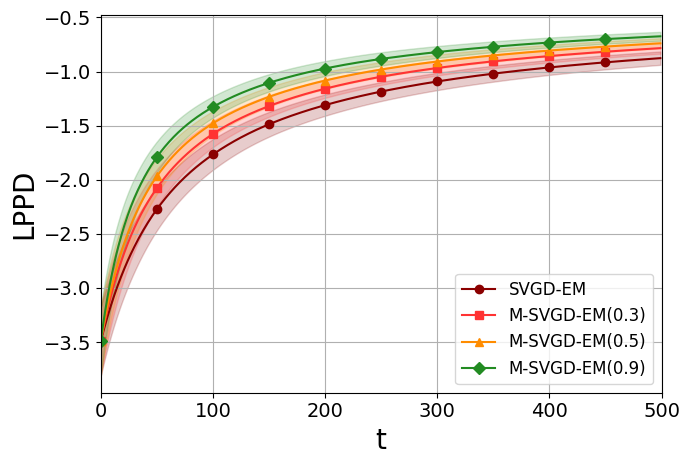

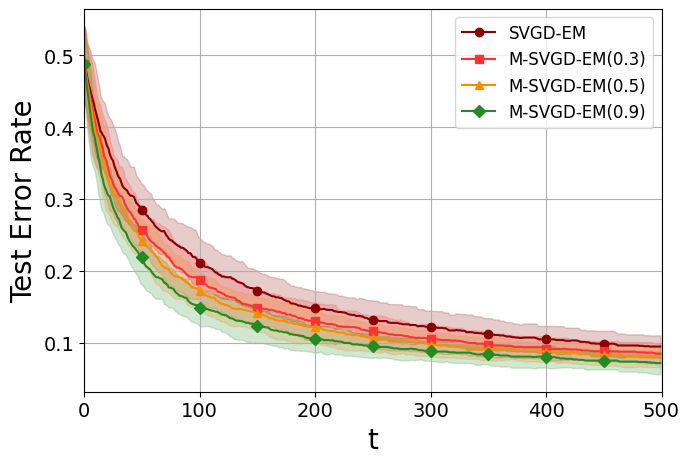

In [67]:
# Create a figure for LPPD
plt.figure(figsize=(7, 5))

N = 10 
    
# Mean and std of LPPD across trials
lppd_00 = jnp.stack([vmap(lambda p: log_pointwise_predrictive_density(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x) for x in results[N]['x_00']])
lppd_03 = jnp.stack([vmap(lambda p: log_pointwise_predrictive_density(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x) for x in results[N]['x_03']])
lppd_05 = jnp.stack([vmap(lambda p: log_pointwise_predrictive_density(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x) for x in results[N]['x_05']])
lppd_09 = jnp.stack([vmap(lambda p: log_pointwise_predrictive_density(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x) for x in results[N]['x_09']])

# Means and standard deviations
lppd_00_mean, lppd_00_std = lppd_00.mean(0), lppd_00.std(0)
lppd_03_mean, lppd_03_std = lppd_03.mean(0), lppd_03.std(0)
lppd_05_mean, lppd_05_std = lppd_05.mean(0), lppd_05.std(0)
lppd_09_mean, lppd_09_std = lppd_09.mean(0), lppd_09.std(0)

iterations = jnp.arange(K)
plt.plot(iterations, lppd_00_mean, label="SVGD-EM", color=method_colors['SVGD-EM'], marker=method_markers['SVGD-EM'], markevery=50)
plt.fill_between(iterations, lppd_00_mean - lppd_00_std, lppd_00_mean + lppd_00_std, color=method_colors['SVGD-EM'], alpha=0.2)

plt.plot(iterations, lppd_03_mean, label="M-SVGD-EM(0.3)", color=method_colors['M-SVGD-EM(0.3)'], marker=method_markers['M-SVGD-EM(0.3)'], markevery=50)
plt.fill_between(iterations, lppd_03_mean - lppd_03_std, lppd_03_mean + lppd_03_std, color=method_colors['M-SVGD-EM(0.3)'], alpha=0.2)

plt.plot(iterations, lppd_05_mean, label="M-SVGD-EM(0.5)", color=method_colors['M-SVGD-EM(0.5)'], marker=method_markers['M-SVGD-EM(0.5)'], markevery=50)
plt.fill_between(iterations, lppd_05_mean - lppd_05_std, lppd_05_mean + lppd_05_std, color=method_colors['M-SVGD-EM(0.5)'], alpha=0.2)

plt.plot(iterations, lppd_09_mean, label="M-SVGD-EM(0.9)", color=method_colors['M-SVGD-EM(0.9)'], marker=method_markers['M-SVGD-EM(0.9)'], markevery=50)
plt.fill_between(iterations, lppd_09_mean - lppd_09_std, lppd_09_mean + lppd_09_std, color=method_colors['M-SVGD-EM(0.9)'], alpha=0.2)

plt.xlabel('t', fontsize=20)
plt.ylabel('LPPD', fontsize=20)
plt.legend(fontsize=12)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(0,500)
plt.grid()
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(save_dir,f'lppd_plot{alpha}and{beta}.pdf'), dpi=300)
plt.show()

plt.figure(figsize=(7, 5))

N = 10  #10 particles
    
# mean and std of test error across trials
error_00 = jnp.stack([vmap(lambda p: test_error(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x) for x in results[N]['x_00']])
error_03 = jnp.stack([vmap(lambda p: test_error(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x) for x in results[N]['x_03']])
error_05 = jnp.stack([vmap(lambda p: test_error(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x) for x in results[N]['x_05']])
error_09 = jnp.stack([vmap(lambda p: test_error(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x) for x in results[N]['x_09']])

# means and standard deviations
error_00_mean, error_00_std = error_00.mean(0), error_00.std(0)
error_03_mean, error_03_std = error_03.mean(0), error_03.std(0)
error_05_mean, error_05_std = error_05.mean(0), error_05.std(0)
error_09_mean, error_09_std = error_09.mean(0), error_09.std(0)

iterations = jnp.arange(K)

plt.plot(iterations, error_00_mean, label="SVGD-EM", color=method_colors['SVGD-EM'], marker=method_markers['SVGD-EM'], markevery=50)
plt.fill_between(iterations, error_00_mean - error_00_std, error_00_mean + error_00_std, color=method_colors['SVGD-EM'], alpha=0.2)

plt.plot(iterations, error_03_mean, label="M-SVGD-EM(0.3)", color=method_colors['M-SVGD-EM(0.3)'], marker=method_markers['M-SVGD-EM(0.3)'], markevery=50)
plt.fill_between(iterations, error_03_mean - error_03_std, error_03_mean + error_03_std, color=method_colors['M-SVGD-EM(0.3)'], alpha=0.2)

plt.plot(iterations, error_05_mean, label="M-SVGD-EM(0.5)", color=method_colors['M-SVGD-EM(0.5)'], marker=method_markers['M-SVGD-EM(0.5)'], markevery=50)
plt.fill_between(iterations, error_05_mean - error_05_std, error_05_mean + error_05_std, color=method_colors['M-SVGD-EM(0.5)'], alpha=0.2)

plt.plot(iterations, error_09_mean, label="M-SVGD-EM(0.9)", color=method_colors['M-SVGD-EM(0.9)'], marker=method_markers['M-SVGD-EM(0.9)'], markevery=50)
plt.fill_between(iterations, error_09_mean - error_09_std, error_09_mean + error_09_std, color=method_colors['M-SVGD-EM(0.9)'], alpha=0.2)

plt.xlabel('t', fontsize=20)
plt.ylabel('Test Error Rate', fontsize=20)
plt.legend(fontsize=12)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(0,500)
plt.grid()
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(save_dir,f'test_error_plot {alpha}and{beta}.pdf'), dpi=300)
plt.show()

In [63]:
end = time.time()
print('Total execution time:',end-start)
#Total execution time: 550.3686113357544 trial 1 alpha 0 beta 0
#Total execution time: 568.1484379768372 trial 2 alpha 0 beta 0
#Total execution time: 611.3417437076569 trial 3 alpha 2 beta 2
#Total execution time: 584.9665582180023 trial 4 alpha 2 beta 2
#Average 578.71 seconds

Total execution time: 584.9665582180023


In [ ]:
h = 1e-1 # Step-size
K = 500  # Number of steps
N = 10   # Number of particles

alpha_values = jnp.arange(-3.0, 3.2, 0.5)
beta_values = jnp.arange(-3.0, 3.2, 0.5)

results_dict = {}
acc_values = [0.0, 0.3, 0.9]

# For global scale
global_min = float('inf')
global_max = float('-inf')

for acc in acc_values:
    results = jnp.zeros((len(alpha_values), len(beta_values)))
    key = jr.PRNGKey(65)

    # combinations alpha beta
    for i, alpha in enumerate(alpha_values):
        for j, beta in enumerate(beta_values):
            print(f"acc={acc}, alpha={alpha}, beta={beta}")
            w_init = jnp.exp(alpha) * jr.normal(key, (N, 40, 28**2))  # Input layer weights
            v_init = jnp.exp(beta) * jr.normal(key, (N, 2, 40))  # Output layer weights

            theta_init = {"alpha": alpha, "beta": beta}
            latent_init = {"w": w_init, "v": v_init}

            model = BayesNN()
            latent_optimiser = ox.adagrad(0.1)
            theta_optimiser = ox.adagrad(0.1)

            # Run M-SVGD-EM
            x_particles, theta_particles = m_svgd_em(model, data, latent_init, theta_init, latent_optimiser, theta_optimiser, K, acc, acc)
            
            error = jnp.stack([vmap(lambda p: test_error(model, p, jnp.array(itest), jnp.array(ltest).reshape(-1, 1)))(x_particles)])
            final_error = error.mean(0)[-1]  # mean across particles and last iteration
            results = results.at[i,j].set(final_error)
    
    results_dict[acc] = results
    global_min = min(global_min, results.min())
    global_max = max(global_max, results.max())

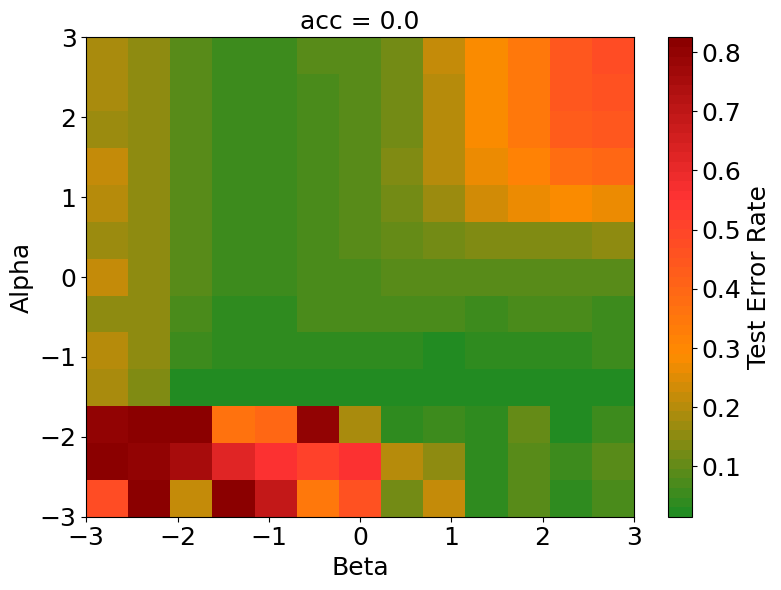

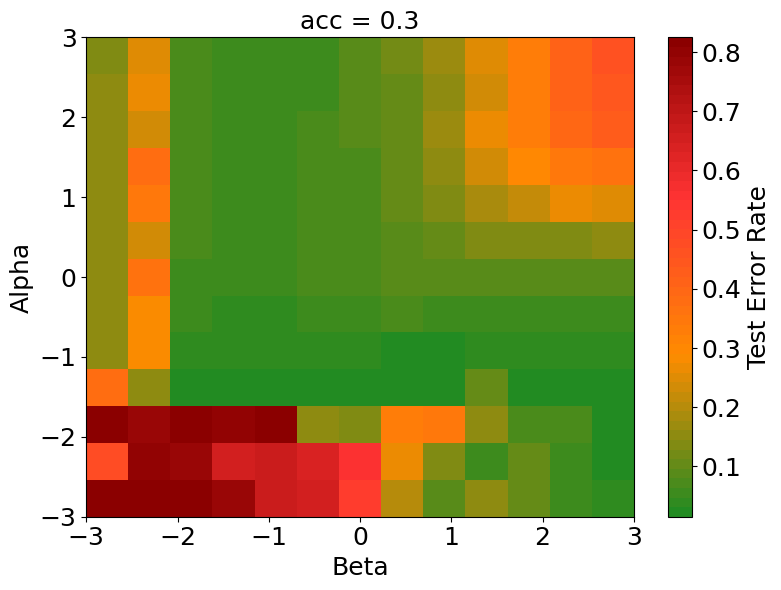

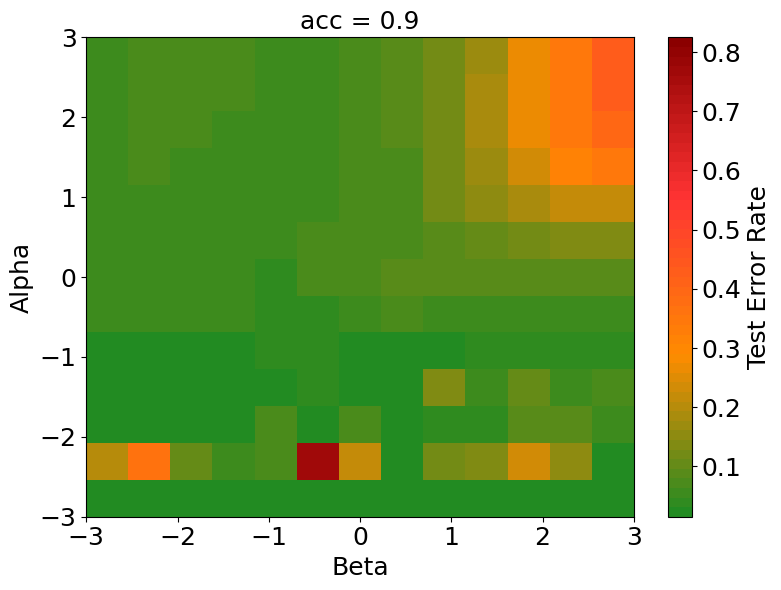

In [ ]:
colors = {
    'c1': '#228B22',     #Green
    'c2': '#FF8C00',     #Orange  
    'c3': '#FF3333',     #Light red
    'c4': '#8B0000'      #Dark red
}
color_list = [colors['c1'], colors['c2'], colors['c3'], colors['c4']]
custom_cmap = LinearSegmentedColormap.from_list("custom_colormap", color_list, N=50)

for idx, acc in enumerate(acc_values):
    fig, ax = plt.subplots(figsize=(8, 6))
    heatmap = ax.imshow(results_dict[acc], cmap=custom_cmap,
                       extent=[-3, 3, -3, 3], aspect='auto', origin='lower',
                       vmin=global_min, vmax=global_max)
    ax.set_xlabel('Beta', fontsize=18)
    ax.set_ylabel('Alpha', fontsize=18)
    ax.tick_params(axis='both', labelsize=18)
    ax.set_title(f'acc = {acc}', fontsize=18)
    ax.grid(False)

    cbar = fig.colorbar(heatmap, ax=ax, label='Test Error Rate')
    cbar.ax.tick_params(labelsize=18)
    cbar.set_label('Test Error Rate', size=18)

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f'alpha_beta_heatmap_acc_{acc}.pdf'), dpi=300)
    plt.show()